In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Manchester City"
away= "Crystal Palace"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,PK,PKm,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
26,Manchester City,Tottenham,2025-02-26,W,A,1,0,1,0,0,...,1.6,0.8,-1.1,-1.1,-1.6,0.18,1,1.6,0.28,1.6
27,Manchester City,Nott'ham Forest,2025-03-08,L,A,0,1,-1,0,0,...,0.6,0.6,-0.9,-0.9,-0.6,0.06,1,0.9,0.21,-0.1
28,Manchester City,Brighton,2025-03-15,D,H,2,2,0,1,0,...,0.8,0.9,0.3,0.1,0.2,0.09,0,0.7,0.22,-0.3
29,Manchester City,Leicester City,2025-04-02,W,H,2,0,2,0,0,...,1.6,2.1,-0.2,-0.2,-0.6,0.12,2,0.0,NaN,0.0
30,Manchester City,Manchester Utd,2025-04-06,D,A,0,0,0,0,0,...,0.2,0.5,-0.5,-0.5,-0.2,0.05,1,0.2,0.08,0.2


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,PK,PKm,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
26,Tottenham,Manchester City,2025-02-26,L,H,0,1,-1,0,0,...,1.3,1.1,-1.3,-1.3,-1.3,0.12,0,2.1,0.42,1.1
27,Nott'ham Forest,Manchester City,2025-03-08,W,H,1,0,1,0,0,...,0.7,0.4,0.3,0.3,0.3,0.08,0,0.5,0.18,0.5
28,Brighton,Manchester City,2025-03-15,D,A,2,2,0,0,0,...,1.7,0.9,-1.0,-1.0,-1.7,0.14,1,1.3,0.18,-0.7
29,Leicester City,Manchester City,2025-04-02,L,A,0,2,-2,0,0,...,0.1,0.1,-0.1,-0.1,-0.1,0.04,0,2.7,0.54,0.7
30,Manchester Utd,Manchester City,2025-04-06,D,H,0,0,0,0,0,...,0.5,1.3,-0.9,-0.9,-0.5,0.07,1,0.3,0.06,0.3


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,PK,PKm,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Crystal Palace,Fulham,2025-02-22,W,A,2,0,2,0,0,...,1.2,0.5,-0.3,-0.3,-0.2,0.13,1,0.0,NaN,0.0
26,Crystal Palace,Aston Villa,2025-02-25,W,H,4,1,3,0,0,...,2.9,0.9,-0.3,-0.3,0.1,0.24,1,1.0,0.51,0.0
27,Crystal Palace,Ipswich Town,2025-03-08,W,H,1,0,1,0,0,...,2.2,1.6,-2.2,-2.2,-2.2,0.17,1,1.6,0.27,1.6
28,Crystal Palace,Southampton,2025-04-02,D,A,1,1,0,0,0,...,0.6,0.6,0.3,0.3,0.4,0.08,1,1.3,0.64,0.3
29,Crystal Palace,Brighton,2025-04-05,W,H,2,1,1,0,0,...,0.5,0.4,1.4,1.4,1.5,0.07,1,1.6,0.32,0.6


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,PK,PKm,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Fulham,Crystal Palace,2025-02-22,L,H,0,2,-2,0,0,...,0.1,0.4,-0.2,-0.2,-0.1,0.02,0,1.4,0.28,0.4
26,Aston Villa,Crystal Palace,2025-02-25,L,A,1,4,-3,0,0,...,0.3,0.8,0.6,0.6,0.7,0.06,0,4.1,0.69,0.1
27,Ipswich Town,Crystal Palace,2025-03-08,L,A,0,1,-1,0,0,...,0.7,0.4,-1.5,-1.5,-0.7,0.13,0,1.3,0.32,0.3
28,Southampton,Crystal Palace,2025-04-02,D,H,1,1,0,0,0,...,0.5,0.6,0.3,0.3,0.5,0.08,0,1.0,0.33,0.0
29,Brighton,Crystal Palace,2025-04-05,L,A,1,2,-1,0,0,...,0.8,0.9,0.0,0.0,0.2,0.09,0,0.9,0.31,-1.1


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'PK', 'PKm', 'G-PK', 'Poss', 'PKatt', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
26,1,0,0,45,0,23,7,30.4,12,52.2,...,0.8,0.8,1.6,0.8,-1.1,-1.1,-1.6,0.18,1,1
27,0,0,0,69,0,25,13,52.0,5,20.0,...,0.1,0.1,0.6,0.6,-0.9,-0.9,-0.6,0.06,1,0
28,1,1,0,60,1,42,21,50.0,14,33.3,...,-0.3,-1.1,0.8,0.9,0.3,0.1,0.2,0.09,0,2
29,2,0,0,72,0,22,12,54.5,9,40.9,...,2.1,2.1,1.6,2.1,-0.2,-0.2,-0.6,0.12,2,2
30,0,0,0,58,0,20,5,25.0,14,70.0,...,-0.4,-0.4,0.2,0.5,-0.5,-0.5,-0.2,0.05,1,0


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
26,0,0,0,55,0,30,9,30.0,15,50.0,...,-0.8,-0.8,1.3,1.1,-1.3,-1.3,-1.3,0.12,0,0
27,1,0,0,31,0,14,7,50.0,5,35.7,...,-0.1,-0.1,0.7,0.4,0.3,0.3,0.3,0.08,0,1
28,1,0,0,40,0,18,6,33.3,6,33.3,...,0.3,1.1,1.7,0.9,-1.0,-1.0,-1.7,0.14,1,2
29,0,0,0,28,0,11,4,36.4,5,45.5,...,-2.1,-2.1,0.1,0.1,-0.1,-0.1,-0.1,0.04,0,0
30,0,0,0,42,0,12,6,50.0,3,25.0,...,0.4,0.4,0.5,1.3,-0.9,-0.9,-0.5,0.07,1,0


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,1,0,0,38,0,16,9,56.3,5,31.3,...,1.1,1.1,1.2,0.5,-0.3,-0.3,-0.2,0.13,1,2
26,4,0,0,36,0,8,4,50.0,4,50.0,...,3.9,3.9,2.9,0.9,-0.3,-0.3,0.1,0.24,1,4
27,1,0,0,55,0,19,9,47.4,7,36.8,...,1.7,1.7,2.2,1.6,-2.2,-2.2,-2.2,0.17,1,1
28,1,0,0,57,0,12,5,41.7,5,41.7,...,0.1,0.1,0.6,0.6,0.3,0.3,0.4,0.08,1,1
29,2,0,0,38,0,17,5,29.4,10,58.8,...,-0.4,-0.4,0.5,0.4,1.4,1.4,1.5,0.07,1,2


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,0,0,0,62,0,15,3,20.0,12,80.0,...,-1.1,-1.1,0.1,0.4,-0.2,-0.2,-0.1,0.02,0,0
26,1,0,0,64,0,29,11,37.9,13,44.8,...,-3.9,-3.9,0.3,0.8,0.6,0.6,0.7,0.06,0,1
27,0,0,0,45,0,26,10,38.5,10,38.5,...,-1.7,-1.7,0.7,0.4,-1.5,-1.5,-0.7,0.13,0,0
28,1,0,0,43,0,20,10,50.0,9,45.0,...,-0.1,-0.1,0.5,0.6,0.3,0.3,0.5,0.08,0,1
29,1,0,0,62,0,19,8,42.1,9,47.4,...,0.4,0.4,0.8,0.9,0.0,0.0,0.2,0.09,0,1


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
26,14,0,0.0,0,0,3.5,0,NaN,0,0,...,2,6,10,30,18,0,1.6,0.28,1.6,0
27,16,1,6.3,0,5,20.1,0,NaN,0,0,...,2,4,5,23,21,1,0.9,0.21,-0.1,1
28,10,1,10.0,0,3,18.2,0,NaN,1,0,...,2,12,4,21,29,2,0.7,0.22,-0.3,2
29,6,0,0.0,0,5,22.3,0,NaN,0,0,...,0,4,3,12,16,0,0.0,NaN,0.0,0
30,13,1,7.7,0,0,6.0,0,NaN,0,0,...,6,4,8,29,21,1,0.2,0.08,0.2,0


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
26,8,1,12.5,0,0,13.3,0,NaN,0,0,...,5,7,7,33,15,0,2.1,0.42,1.1,1
27,9,0,0.0,0,0,NaN,0,NaN,0,0,...,3,10,5,22,30,2,0.5,0.18,0.5,0
28,7,0,0.0,1,0,2.0,0,0.0,0,0,...,1,4,10,37,28,2,1.3,0.18,-0.7,2
29,10,1,10.0,0,0,6.0,0,NaN,0,0,...,8,4,6,25,24,1,2.7,0.54,0.7,2
30,5,1,20.0,0,0,6.0,0,NaN,0,0,...,1,6,15,47,18,0,0.3,0.06,0.3,0


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,14,0,0.0,0,2,26.0,0,NaN,0,0,...,1,9,5,27,29,1,2.4,0.62,0.4,2
1,8,0,0.0,0,0,2.0,0,NaN,0,0,...,5,6,9,32,12,0,0.9,0.30,-1.1,2
2,15,2,13.3,0,0,5.0,0,NaN,0,0,...,1,4,6,25,30,0,2.7,0.39,1.7,1
3,7,0,0.0,0,2,17.5,0,NaN,0,0,...,1,9,8,32,13,2,2.2,0.55,0.2,2
4,17,3,17.6,0,4,17.9,0,NaN,0,0,...,3,10,13,35,31,1,1.8,0.32,1.8,0


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,11,1,9.1,0,2,14.9,0,NaN,0,0,...,4,9,11,30,20,0,1.0,0.17,1.0,1
1,15,1,6.7,0,1,16.8,0,NaN,0,0,...,4,6,15,35,25,0,0.3,0.13,0.3,0
2,6,1,16.7,0,7,19.6,0,NaN,0,0,...,5,8,8,21,18,0,1.1,0.36,0.1,1
3,21,1,4.8,1,0,5.3,0,0.0,0,0,...,10,16,8,27,22,0,1.8,0.25,-0.2,2
4,11,0,0.0,0,1,14.0,0,NaN,0,0,...,2,6,9,23,15,0,0.5,0.13,0.5,0


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
26,5,8,38.5,0,0,0,15,12,35
27,7,10,41.2,2,0,0,7,9,39
28,12,12,50.0,2,0,0,10,9,37
29,10,7,58.8,1,0,0,11,8,36
30,7,7,50.0,2,0,0,9,12,37


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
26,8,5,61.5,3,0,0,12,14,44
27,10,7,58.8,3,0,0,9,7,36
28,12,12,50.0,5,0,0,10,9,39
29,7,10,41.2,4,0,0,8,11,24
30,7,7,50.0,3,0,0,13,9,42


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,9,16,36.0,3,0,0,7,10,40
26,9,13,40.9,3,0,0,19,10,46
27,21,22,48.8,4,0,0,8,7,46
28,13,16,44.8,1,0,0,9,12,46
29,9,19,32.1,4,2,2,12,13,33


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,16,9,64.0,1,0,0,10,7,51
26,13,9,59.1,1,0,0,10,19,43
27,22,21,51.2,3,0,0,7,8,46
28,16,13,55.2,2,0,0,14,8,41
29,19,9,67.9,3,1,1,13,10,44


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
26,1,0,0,45,0,23,7,30.4,12,52.2,...,0.625,1.138347,0.675,1.068878,0.1250,0.061373,0.50,0.577350,2.00,1.825742
27,0,0,0,69,0,25,13,52.0,5,20.0,...,0.150,1.405940,0.075,1.543535,0.1275,0.063966,0.50,0.577350,1.50,1.732051
28,1,1,0,60,1,42,21,50.0,14,33.3,...,-0.125,1.497498,-0.125,1.573478,0.1125,0.072744,0.75,0.500000,1.25,1.892969
29,2,0,0,72,0,22,12,54.5,9,40.9,...,-0.625,0.525198,-0.600,0.748331,0.0925,0.061847,0.75,0.500000,0.75,0.957427
30,0,0,0,58,0,20,5,25.0,14,70.0,...,-0.525,0.567891,-0.650,0.737111,0.1125,0.051235,1.00,0.816497,1.25,0.957427


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
26,0,0,0,55,0,30,9,30.0,15,50.0,...,1.000,2.204541,8.500000e-01,1.799074,0.1275,0.049917,0.00,0.0,2.00,2.160247
27,1,0,0,31,0,14,7,50.0,5,35.7,...,0.875,2.350000,7.000000e-01,1.986622,0.1125,0.035940,0.00,0.0,1.75,2.362908
28,1,0,0,40,0,18,6,33.3,6,33.3,...,-0.050,1.112055,-6.938894e-17,1.194432,0.1125,0.035940,0.00,0.0,0.75,0.957427
29,0,0,0,28,0,11,4,36.4,5,45.5,...,-0.175,1.203813,-3.000000e-01,1.478738,0.1075,0.027538,0.25,0.5,1.25,0.957427
30,0,0,0,42,0,12,6,50.0,3,25.0,...,-0.525,0.750000,-7.000000e-01,0.952190,0.0950,0.044347,0.25,0.5,0.75,0.957427


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,15,1,6.7,0,0,11.0,0,0.0,0,0,...,0.75,1.500000,0.875,0.767572,0.220000,0.040000,-0.125,0.505800,1.00,1.154701
26,10,0,0.0,0,0,20.0,0,0.0,0,0,...,0.75,1.500000,0.875,0.767572,0.220000,0.040000,-0.125,0.505800,1.00,1.154701
27,14,0,0.0,0,1,7.8,0,0.0,0,0,...,0.75,1.500000,0.700,0.571548,0.330000,0.157162,-0.050,0.493288,0.75,0.957427
28,11,0,0.0,0,0,0.0,0,0.0,0,0,...,1.25,1.500000,0.975,0.694622,0.333333,0.155027,0.225,0.974252,0.75,0.957427
29,18,1,5.6,0,5,17.5,0,0.0,0,0,...,0.75,0.957427,0.975,0.694622,0.473333,0.187705,0.475,0.763217,0.50,0.577350


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,10,0,0.0,0,1,17.0,0,0.0,0,0,...,1.25,1.258306,1.375,0.434933,0.2375,0.080156,-0.125,0.869387,1.50,0.577350
26,11,0,0.0,0,0,13.0,0,0.0,0,1,...,1.00,1.414214,1.325,0.411299,0.2775,0.017078,0.075,0.877021,1.50,0.577350
27,17,2,11.8,0,0,8.2,0,0.0,0,0,...,0.50,0.577350,2.025,1.443087,0.3850,0.203715,0.025,0.865544,2.25,1.258306
28,13,2,15.4,0,0,7.0,0,0.0,0,0,...,1.00,0.816497,2.150,1.317826,0.3975,0.195683,0.400,0.294392,2.00,1.414214
29,8,2,25.0,0,3,14.4,0,0.0,0,0,...,1.00,0.816497,1.950,1.443376,0.4050,0.191224,0.200,0.182574,2.00,1.414214


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,1,0,0,38,0,16,9,56.3,5,31.3,...,-0.200,0.522813,-0.075,0.567891,0.1150,0.085829,0.50,1.000000,1.50,0.577350
26,4,0,0,36,0,8,4,50.0,4,50.0,...,-0.400,0.244949,-0.250,0.420317,0.1350,0.074162,0.75,0.957427,1.50,0.577350
27,1,0,0,55,0,19,9,47.4,7,36.8,...,-0.450,0.173205,-0.300,0.336650,0.1775,0.073201,0.50,0.577350,2.25,1.258306
28,1,0,0,57,0,12,5,41.7,5,41.7,...,-0.850,0.911043,-0.675,1.037224,0.1600,0.060553,0.75,0.500000,2.00,1.414214
29,2,0,0,38,0,17,5,29.4,10,58.8,...,-0.625,1.087428,-0.475,1.175798,0.1550,0.067577,1.00,0.000000,2.00,1.414214


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,0,0,0,62,0,15,3,20.0,12,80.0,...,5.000000e-02,0.957427,-0.100,0.683130,0.0600,0.024495,0.25,0.5,1.00,1.154701
26,1,0,0,64,0,29,11,37.9,13,44.8,...,7.500000e-02,0.946485,-0.075,0.680074,0.0550,0.031091,0.25,0.5,1.00,1.154701
27,0,0,0,45,0,26,10,38.5,10,38.5,...,1.000000e-01,0.962635,-0.050,0.714143,0.0600,0.029439,0.00,0.0,0.75,0.957427
28,1,0,0,43,0,20,10,50.0,9,45.0,...,-5.551115e-17,1.134313,0.025,0.585235,0.0750,0.046547,0.00,0.0,0.75,0.957427
29,1,0,0,62,0,19,8,42.1,9,47.4,...,-2.000000e-01,0.927362,0.100,0.632456,0.0725,0.045735,0.00,0.0,0.50,0.577350


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
26,14,0,0.0,0,0,3.5,0,0.0,0,0,...,2.00,1.414214,1.650,1.075484,0.400000,0.049666,-0.350,1.247664,2.00,2.160247
27,16,1,6.3,0,5,20.1,0,0.0,0,0,...,1.75,1.707825,1.600,1.070825,0.357500,0.063443,-0.150,1.526434,1.75,2.362908
28,10,1,10.0,0,3,18.2,0,0.0,1,0,...,1.00,0.816497,1.075,0.537742,0.302500,0.074106,0.325,0.942956,0.75,0.957427
29,6,0,0.0,0,5,22.3,0,0.0,0,0,...,1.25,0.957427,1.150,0.420317,0.262500,0.060208,0.150,0.988264,1.25,0.957427
30,13,1,7.7,0,0,6.0,0,0.0,0,0,...,0.75,0.957427,0.800,0.658281,0.236667,0.037859,0.300,0.875595,0.75,0.957427


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
26,8,1,12.5,0,0,13.3,0,0.0,0,0,...,0.75,0.957427,1.575,1.078193,0.2800,0.146742,-0.425,0.750000,2.00,1.825742
27,9,0,0.0,0,0,0.0,0,0.0,0,0,...,0.25,0.500000,1.575,1.078193,0.2875,0.154785,0.075,0.963933,1.50,1.732051
28,7,0,0.0,1,0,2.0,0,0.0,0,0,...,0.75,0.957427,1.450,1.190238,0.2675,0.164393,0.200,0.983192,1.25,1.892969
29,10,1,10.0,0,0,6.0,0,0.0,0,0,...,1.00,1.154701,1.075,0.793200,0.2150,0.144568,0.325,0.750000,0.75,0.957427
30,5,1,20.0,0,0,6.0,0,0.0,0,0,...,1.25,0.957427,1.650,0.957427,0.3300,0.180000,0.400,0.774597,1.25,0.957427


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
26,5,8,38.5,0,0,0,15,12,35,6.5,...,0.0,0.0,0.0,0.0,5.25,1.707825,9.00,2.943920,40.25,6.075909
27,7,10,41.2,2,0,0,7,9,39,6.0,...,0.0,0.0,0.0,0.0,7.50,5.259911,10.00,3.162278,39.25,6.652067
28,12,12,50.0,2,0,0,10,9,37,6.0,...,0.0,0.0,0.0,0.0,7.50,5.259911,10.75,2.061553,40.25,6.075909
29,10,7,58.8,1,0,0,11,8,36,7.0,...,0.0,0.0,0.0,0.0,8.75,5.057997,9.75,1.500000,40.00,6.218253
30,7,7,50.0,2,0,0,9,12,37,8.5,...,0.0,0.0,0.0,0.0,10.75,3.304038,9.50,1.732051,36.75,1.707825


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
26,8,5,61.5,3,0,0,12,14,44,5.75,...,0.0,0.0,0.0,0.0,9.25,2.986079,5.25,1.707825,35.50,3.511885
27,10,7,58.8,3,0,0,9,7,36,5.75,...,0.0,0.0,0.0,0.0,10.25,3.095696,7.25,4.787136,38.25,4.924429
28,12,12,50.0,5,0,0,10,9,39,6.75,...,0.0,0.0,0.0,0.0,11.00,1.825742,7.25,4.787136,37.50,5.000000
29,7,10,41.2,4,0,0,8,11,24,8.50,...,0.0,0.0,0.0,0.0,10.25,1.258306,8.25,4.573474,39.25,3.403430
30,7,7,50.0,3,0,0,13,9,42,9.25,...,0.0,0.0,0.0,0.0,9.75,1.707825,10.25,2.986079,35.75,8.500000


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
25,9,16,36.0,3,0,0,7,10,40,17.00,...,0.0,0.0,0.0,0.0,10.00,2.160247,11.50,1.290994,46.00,7.874008
26,9,13,40.9,3,0,0,19,10,46,16.75,...,0.0,0.0,0.0,0.0,9.25,2.629956,10.75,0.957427,46.75,6.800735
27,21,22,48.8,4,0,0,8,7,46,14.50,...,0.0,0.0,0.0,0.0,12.00,5.291503,10.50,1.000000,46.50,6.806859
28,13,16,44.8,1,0,0,9,12,46,15.25,...,0.0,0.0,0.0,0.0,10.75,5.560276,9.75,2.061553,44.00,2.828427
29,9,19,32.1,4,2,2,12,13,33,13.00,...,0.0,0.0,0.0,0.0,10.75,5.560276,9.75,2.061553,44.50,3.000000


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
25,16,9,64.0,1,0,0,10,7,51,21.75,...,0.25,0.5,0.25,0.5,12.00,0.816497,9.75,1.707825,45.75,4.787136
26,13,9,59.1,1,0,0,10,19,43,21.50,...,0.00,0.0,0.00,0.0,11.25,0.957427,9.00,2.160247,47.50,5.196152
27,22,21,51.2,3,0,0,7,8,46,20.00,...,0.00,0.0,0.00,0.0,11.00,1.154701,11.75,5.251984,46.25,5.619905
28,16,13,55.2,2,0,0,14,8,41,20.75,...,0.00,0.0,0.00,0.0,9.75,2.061553,10.75,5.560276,45.00,4.690416
29,19,9,67.9,3,1,1,13,10,44,16.75,...,0.00,0.0,0.00,0.0,10.25,2.872281,10.50,5.686241,45.25,4.349329


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,0,0,0,58,0,20,5,25.0,14,70.0,...,0.957427,0.975,0.694622,0.473333,0.187705,0.475,0.763217,0.5,0.57735,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,2,0,0,52,0,30,15,50.0,8,26.7,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,4
1,3,1,0,75,1,20,11,55.0,7,35.0,...,0.0,0.0,15.000000,0.000000,6.000000,0.000000,49.000000,0.000000,A,3
2,3,0,0,67,0,19,12,63.2,3,15.8,...,0.0,0.0,12.000000,4.242641,11.000000,7.071068,48.000000,1.414214,H,2
3,2,0,0,54,0,14,3,21.4,8,57.1,...,0.0,0.0,12.333333,3.055050,10.333333,5.131601,42.333333,9.865766,H,2
4,2,0,0,77,0,21,10,47.6,9,42.9,...,0.0,0.0,12.000000,2.581989,11.250000,4.573474,42.750000,8.098354,A,1


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,13,1,7.7,0,0,6.0,0,0.0,0,0,...,0.0,0.0,0.0,10.75,5.560276,9.75,2.061553,44.5,3.0,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,12,1,8.3,0,0,11.0,0,0.0,0,0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,1
1,5,0,0.0,0,1,19.5,0,0.0,0,0,...,0.0,0.0,15.000000,0.000000,6.000000,0.000000,49.000000,0.000000,A,1
2,10,0,0.0,0,2,24.0,0,0.0,0,0,...,0.0,0.0,12.000000,4.242641,11.000000,7.071068,48.000000,1.414214,H,1
3,9,0,0.0,0,6,16.3,0,0.0,0,0,...,0.0,0.0,12.333333,3.055050,10.333333,5.131601,42.333333,9.865766,H,2
4,7,0,0.0,0,2,23.3,0,0.0,0,1,...,0.0,0.0,12.000000,2.581989,11.250000,4.573474,42.750000,8.098354,A,1


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,2,0,0,38,0,17,5,29.4,10,58.8,...,0.0,0.0,0.0,10.75,5.560276,9.75,2.061553,44.5,3.0,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,0.0,0.0,0.0,54.0,0.0,18.0,3.0,16.7,14.0,77.8,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,0.0
1,0.0,0.0,0.0,58.0,0.0,14.0,3.0,21.4,11.0,78.6,...,0.0,0.0,15.000000,0.000000,6.000000,0.000000,49.000000,0.000000,A,1.0
2,1.0,0.0,0.0,38.0,0.0,13.0,6.0,46.2,7.0,53.8,...,0.0,0.0,12.000000,4.242641,11.000000,7.071068,48.000000,1.414214,H,2.0
3,1.0,1.0,0.0,66.0,1.0,10.0,4.0,40.0,5.0,50.0,...,0.0,0.0,12.333333,3.055050,10.333333,5.131601,42.333333,9.865766,H,0.0
4,0.0,0.0,0.0,33.0,0.0,13.0,4.0,30.8,6.0,46.2,...,0.0,0.0,12.000000,2.581989,11.250000,4.573474,42.750000,8.098354,A,1.0


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,18,1,5.6,0,5,17.5,0,0.0,0,0,...,0.0,0.0,0.0,10.75,5.560276,9.75,2.061553,44.5,3.0,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,14.0,0.0,0.0,0.0,2.0,26.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,H,2.0
1,8.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,15.000000,0.000000,6.000000,0.000000,49.000000,0.000000,A,1.0
2,15.0,2.0,13.3,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,12.000000,4.242641,11.000000,7.071068,48.000000,1.414214,H,2.0
3,7.0,0.0,0.0,0.0,2.0,17.5,0.0,0.0,0.0,0.0,...,0.0,0.0,12.333333,3.055050,10.333333,5.131601,42.333333,9.865766,H,0.0
4,17.0,3.0,17.6,0.0,4.0,17.9,0.0,0.0,0.0,0.0,...,0.0,0.0,12.000000,2.581989,11.250000,4.573474,42.750000,8.098354,A,2.0


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

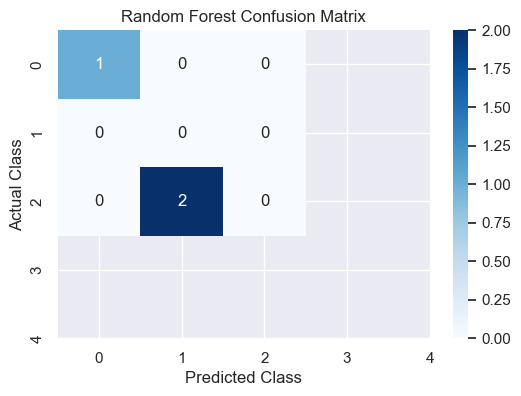

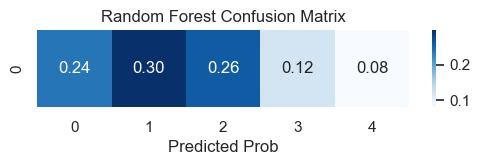

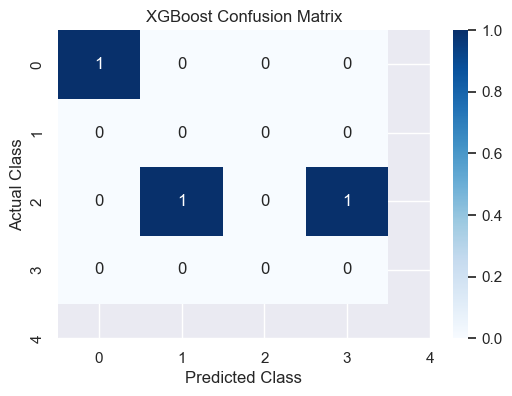

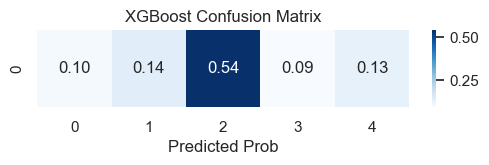

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

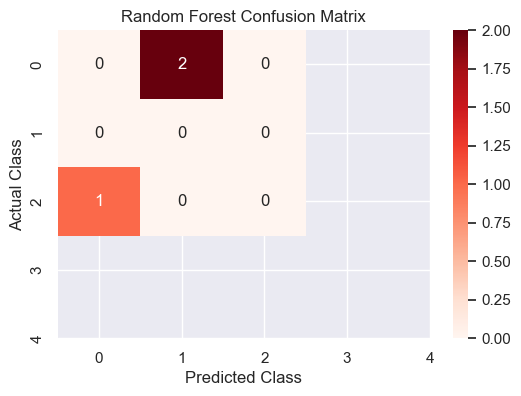

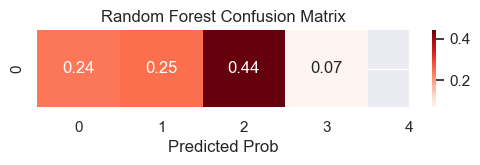

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3], got [0 1 2 4]

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

ValueError: Found unknown categories [0] in column 0 during transform

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

ValueError: Found unknown categories [0] in column 0 during transform

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

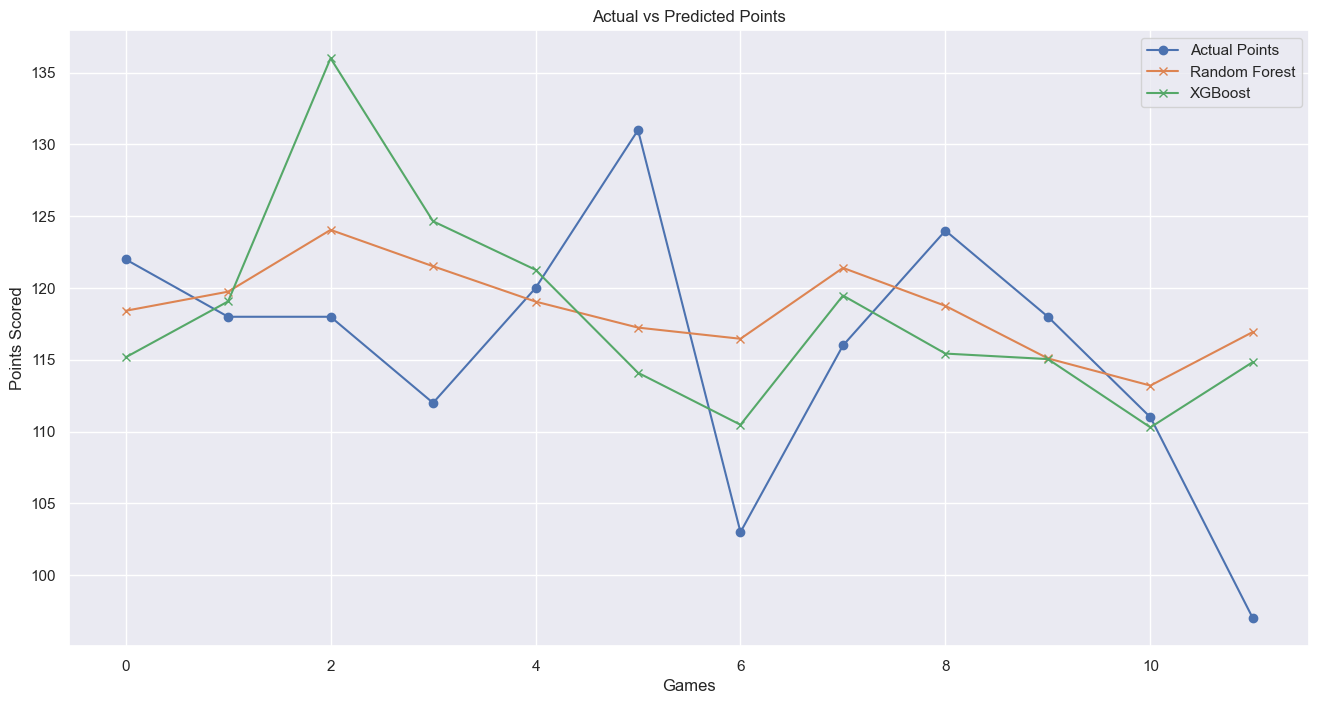

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
